In [17]:
# %pip install scikit-learn
# %pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

In [18]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")


라이브러리 로드


# **[시작] 카메라 호출**

### 카메라 설정

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


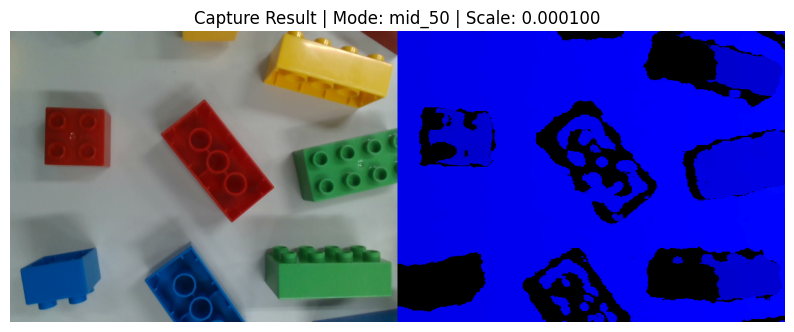

✅ 카메라 스트리밍 안전 종료 완료.


In [19]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 8비트 RGB 이미지, 16비트 뎁스, 인트린직, 뎁스 스케일 출력
# 카메라 모드 별로 설정 변경 가능

color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

color_img_bgr = color_rgb.copy()
color_img_bgr = cv2.cvtColor(color_img_bgr, cv2.COLOR_RGB2BGR)

# color_img_rgb (ndarray): RGB 포맷의 컬러 이미지 (YOLO, Open3D용)
# depth_img (ndarray): Raw 뎁스 이미지
# intrinsics (rs.intrinsics): 카메라 내부 파라미터 (3D 투영용)
# depth_scale (float): 뎁스 단위를 미터(m)로 변환하기 위한 스케일 값 (매우 중요)

# **욜로 인지**

### **YOLO V8 세그멘테이션 기준 영역 잡기**

🎯 [SUCCESS] 13개의 타겟 객체 마스크 병합 완료


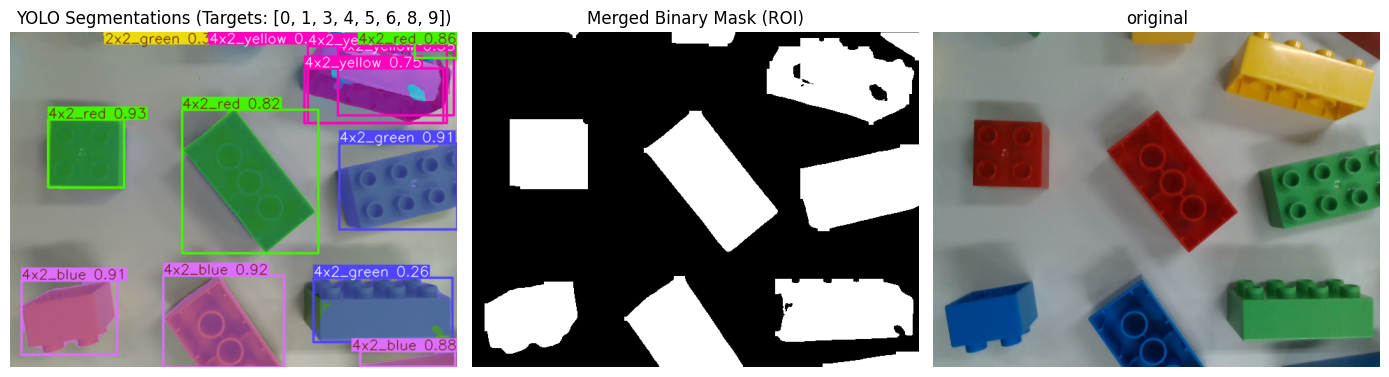

In [20]:
# color_rgb, depth, intrinsics, scale

# 욜로 검출
model = YOLO("yolo_models/duplo_2_low_2/weights/best.pt")
# model = YOLO("yolo_models/manip_segmentor_0528.pt")
target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
    model= model, 
    color_img_bgr=color_img_bgr, 
    target_classes=target_classes, 
    visualize=True
)

# results (list): YOLO 모델의 원본 추론 결과 객체 리스트
# mask_binary (ndarray): 검출된 모든 객체의 마스크를 하나로 합친 이진 마스크 (0 or 1, 형태: H x W)
# vis_yolo (ndarray): 바운딩 박스와 라벨이 그려진 시각화용 이미지 (BGR)

### 바운딩 박스가 겹치는 부분을 억제하는 전처리 추가

✂️ [INFO] 억제됨: '4x2_yellow' (면적:6824)가 '4x2_yellow' (면적:8988)에 95.5% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 12개
 - 🏷️ 4x2_red (신뢰도: 0.82)
 - 🏷️ 4x2_green (신뢰도: 0.26)
 - 🏷️ 4x2_green (신뢰도: 0.91)
 - 🏷️ 4x2_blue (신뢰도: 0.92)
 - 🏷️ 4x2_red (신뢰도: 0.93)
 - 🏷️ 4x2_blue (신뢰도: 0.91)
 - 🏷️ 4x2_yellow (신뢰도: 0.38)
 - 🏷️ 4x2_yellow (신뢰도: 0.69)
 - 🏷️ 4x2_blue (신뢰도: 0.88)
 - 🏷️ 4x2_yellow (신뢰도: 0.64)
 - 🏷️ 4x2_red (신뢰도: 0.86)
 - 🏷️ 2x2_green (신뢰도: 0.35)


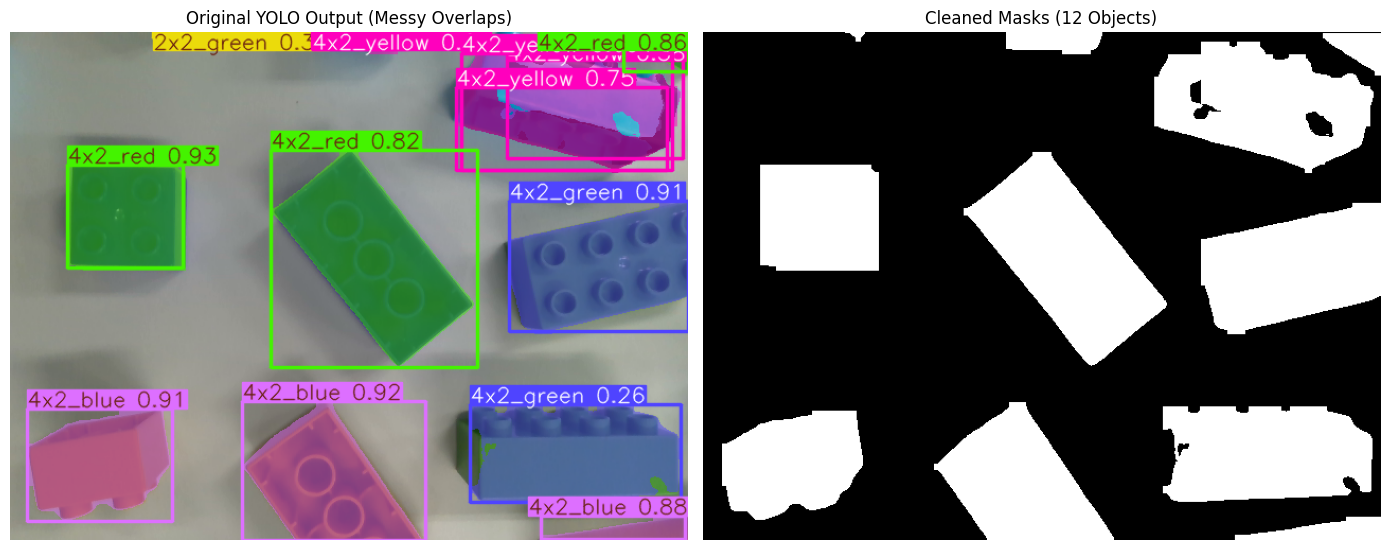


✅ 최종 검출된 유효 객체/군집 수: 12개
 - Name: 4x2_red
 - Name: 4x2_green
 - Name: 4x2_green
 - Name: 4x2_blue
 - Name: 4x2_red
 - Name: 4x2_blue
 - Name: 4x2_yellow
 - Name: 4x2_yellow
 - Name: 4x2_blue
 - Name: 4x2_yellow
 - Name: 4x2_red
 - Name: 2x2_green


In [21]:
# 겹치는 마스크 깔끔하게 정리 (해상도 640x480 기준, 70% 겹치면 삭제, 시각화 켬)
final_objects, clean_mask = ivl.filter_overlapping_masks(
    results=results, 
    overlap_threshold=0.70, 
    img_shape=(640, 480), 
    visualize=True
)

# final_detected_objects (list): 억제 후 살아남은 최종 객체들의 리스트. 
#                                 각 요소는 dict 형태 (class_id, class_name, confidence, mask)
# final_combined_mask (ndarray): 병합된 최종 전체 ROI 마스크 (0 or 1, uint8)

print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

### Ransac 바닥 검출 후 높이 + 비율 기반 ID 수정

In [22]:
import copy

# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
# 기존의 바닥 다림질과 돌출 맵 추출 과정이 하나의 함수로 처리됩니다.
# 반환된 closed_mask가 곧 40mm 이상 돌출된 객체의 2D 마스크(mask_40mm_2d)입니다.
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_img_bgr, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=5.0,
    height_threshold=0.040,
    visualize=False
)

# print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
# final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
# for obj in final_objects:
#     print(f" - Name: {obj['class_name']}")
#     final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

# =================================================================
# [STEP 3] 최종 OBB 기반 ID 판독 및 교정
# =================================================================

final_objects_before = copy.deepcopy(final_objects)

final_objects, result_vis_img = ivl.correct_object_ids(
    detected_objects=final_objects, 
    mask_high_2d=mask_40mm_2d, 
    color_img_bgr=color_img_bgr, 
    ratio_threshold=1.5, 
    overlap_threshold=0.20, 
    visualize=False
)

final_objects_after = copy.deepcopy(final_objects)

final_objects_after = ivl.add_side2_suffix_for_high_corrected_objects(
    objects_before=final_objects_before,
    objects_after=final_objects_after,
    mask_40mm_2d=mask_40mm_2d,
    overlap_threshold=0.20,
    only_changed=False,      # ID가 바뀐 객체만 _side2
    remove_c_prefix=False
)

for i, obj in enumerate(final_objects_after):
    print(i, obj.keys())
    print("class:", obj["class_name"])
    print("mask shape:", obj["mask"].shape, "dtype:", obj["mask"].dtype, "unique:", np.unique(obj["mask"])[:10])
    print()

# =================================================================
# [STEP 3-1] ID 교정 후 마스크 내부 채우기
# =================================================================

objects_filled = copy.deepcopy(final_objects_after)

mask_before = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_after = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

for obj in objects_filled:
    original_mask = (obj["mask"] > 0).astype(np.uint8)

    filled_mask = ivl.fill_object_mask_holes(original_mask)

    obj["mask"] = filled_mask.astype(bool)

    mask_before = np.logical_or(mask_before, original_mask > 0).astype(np.uint8)
    mask_after = np.logical_or(mask_after, filled_mask > 0).astype(np.uint8)





# =================================================================
# [STEP 3-1] ID 교정 후 마스크 Convex Hull로 내부 채우기
# =================================================================

objects_hull = copy.deepcopy(objects_filled)

mask_before = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_hull_after = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

for obj in objects_hull:
    original_mask = (obj["mask"] > 0).astype(np.uint8)

    # Convex Hull로 객체 영역 재생성
    hull_mask = ivl.fill_object_mask_by_convex_hull(
        original_mask,
        min_area=20
    )

    # 객체별 mask를 hull 결과로 교체
    obj["mask"] = hull_mask.astype(bool)

    # 전체 before / after 통합 마스크
    mask_before = np.logical_or(mask_before, original_mask > 0).astype(np.uint8)
    mask_hull_after = np.logical_or(mask_hull_after, hull_mask > 0).astype(np.uint8)



[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: -0.081x + 0.004y + 0.997z + 0.226 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 0개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.12). '4x2_red' -> '2x2_red'
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.49). '4x2_blue' -> '2x2_blue'
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.38). '4x2_red' -> '2x2_red'
0 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_red
mask shape: (480, 640) dtype: bool unique: [False  True]

1 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_green
mask shape: (480, 640) dtype: bool unique: [False  True]

2 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_green
mask shape: (480, 640) dtype: bool unique: [False  True]

3 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_blue
mask shape: (480, 640) dtype: boo

### 디버깅용 - 어떤 객체가 변경되었는지 하이라이트


[ID 변경 목록]
 - index 4: 4x2_red -> 2x2_red
 - index 5: 4x2_blue -> 2x2_blue
 - index 10: 4x2_red -> 2x2_red


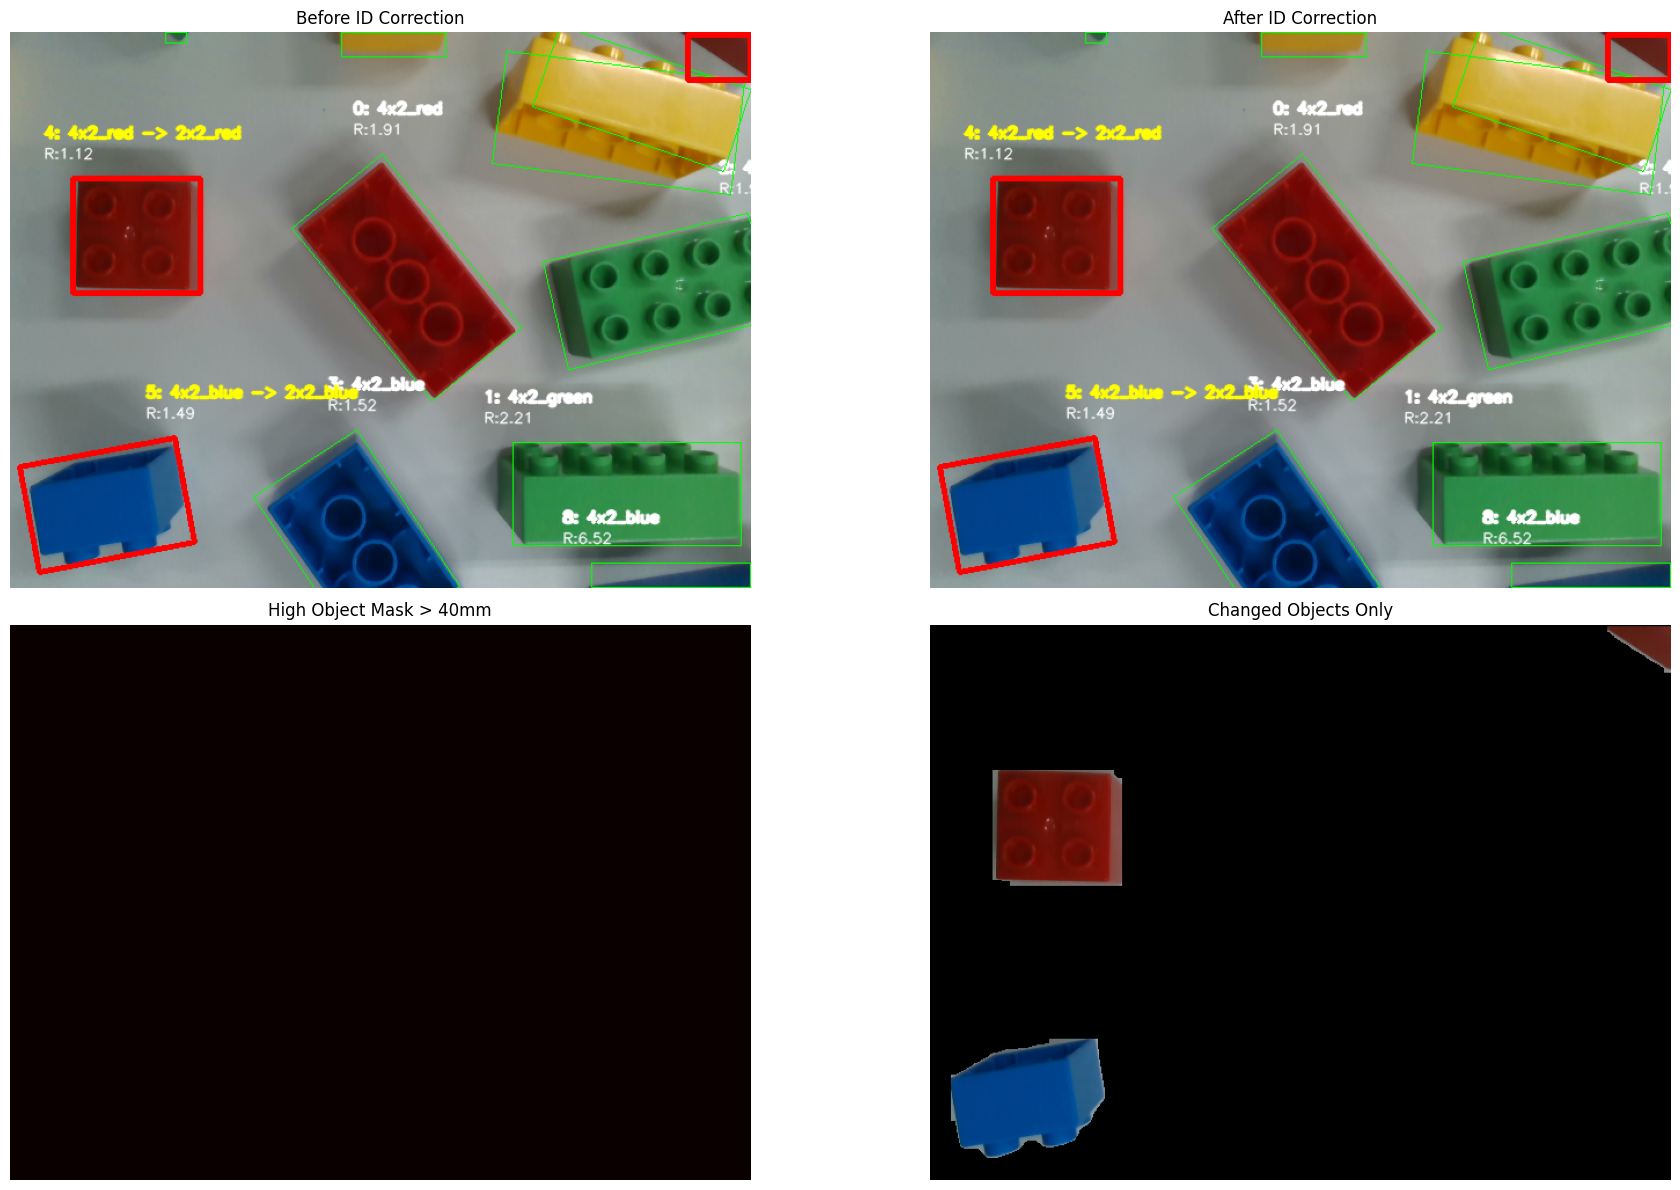

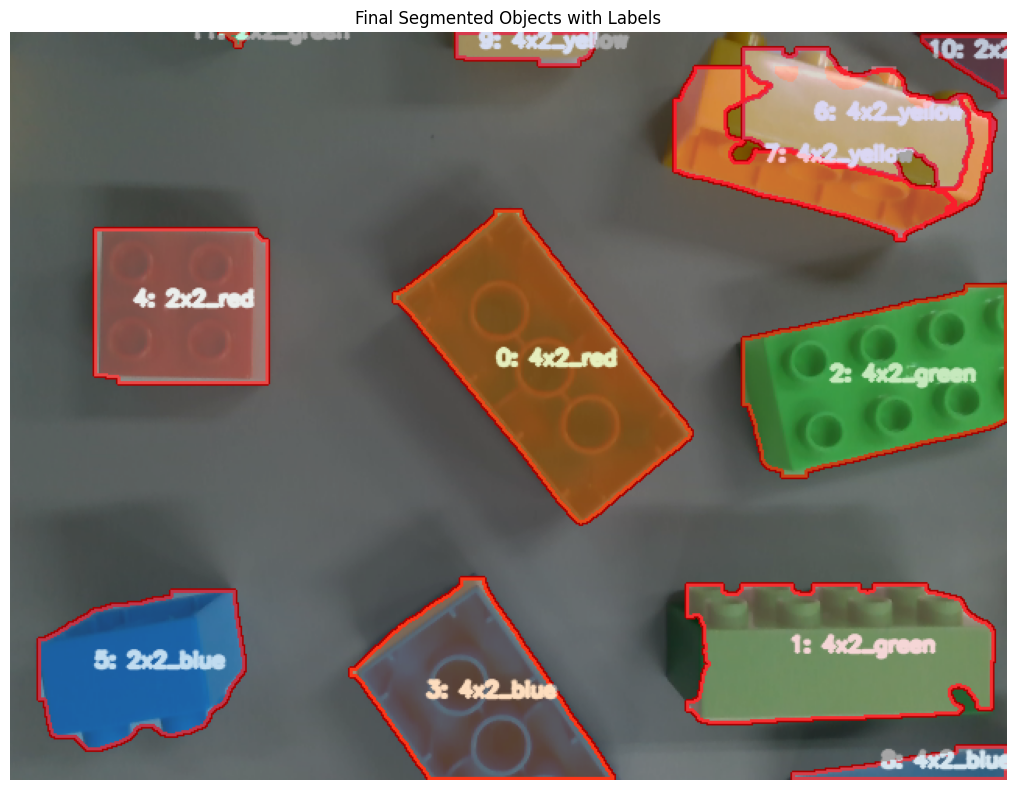

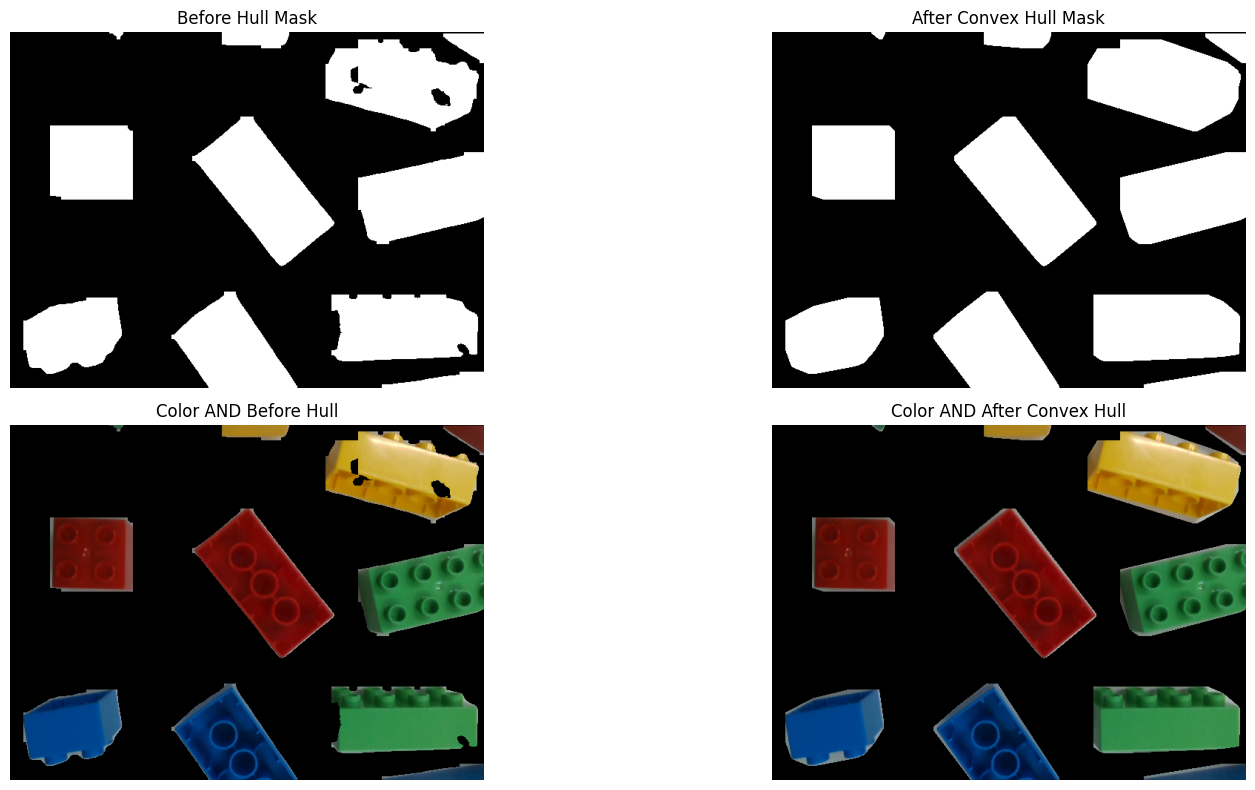

In [23]:
vis_result = ivl.visualize_id_correction_and_final_segments(
    color_img_bgr=color_img_bgr,
    final_objects_before=final_objects_before,
    final_objects_after=objects_filled,
    mask_40mm_2d=mask_40mm_2d,
    show=True
)

color_before_bgr = cv2.bitwise_and(
    color_img_bgr,
    color_img_bgr,
    mask=(mask_before * 255).astype(np.uint8)
)

color_hull_bgr = cv2.bitwise_and(
    color_img_bgr,
    color_img_bgr,
    mask=(mask_hull_after * 255).astype(np.uint8)
)

plt.figure(figsize=(18, 8))

plt.subplot(2, 2, 1)
plt.imshow(mask_before, cmap="gray")
plt.title("Before Hull Mask")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mask_hull_after, cmap="gray")
plt.title("After Convex Hull Mask")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(color_before_bgr, cv2.COLOR_BGR2RGB))
plt.title("Color AND Before Hull")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(color_hull_bgr, cv2.COLOR_BGR2RGB))
plt.title("Color AND After Convex Hull")
plt.axis("off")

plt.tight_layout()
plt.show()

### 상하측면 구분 하기

4*2 세워진거 없애고,

욜로 영역 빼고 전부 비활성화 한다음에

대비랑 조도 만지고,

허프 서클 검출해서

원 몇개인지 보고, 이거 전부 선으로 잇는데,

원들이 하나의 점이나, 세개가 이어져서 선으로만 끝나면 아랫면,

적어도 하나의 끝나는 면이 있다면, 닫힌 부분의 면이 생성되면 윗면,



In [24]:
# =================================================================
# [STEP 3-2] side2 객체를 제외한 Convex Hull 마스크 생성
# =================================================================

mask_no_side2 = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_side2_only = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

objects_no_side2 = []
objects_side2 = []

for idx, obj in enumerate(objects_hull):
    class_name = obj["class_name"]
    obj_mask = (obj["mask"] > 0).astype(np.uint8)

    if "side2" in class_name:
        objects_side2.append(obj)
        mask_side2_only = np.logical_or(mask_side2_only, obj_mask > 0).astype(np.uint8)
        print(f"[REMOVE side2] idx {idx}: {class_name}")
    else:
        objects_no_side2.append(obj)
        mask_no_side2 = np.logical_or(mask_no_side2, obj_mask > 0).astype(np.uint8)
        print(f"[KEEP] idx {idx}: {class_name}")

mask_no_side2_255 = (mask_no_side2 * 255).astype(np.uint8)

color_no_side2_bgr = cv2.bitwise_and(
    color_img_bgr,
    color_img_bgr,
    mask=mask_no_side2_255
)

[KEEP] idx 0: 4x2_red
[KEEP] idx 1: 4x2_green
[KEEP] idx 2: 4x2_green
[KEEP] idx 3: 4x2_blue
[KEEP] idx 4: 2x2_red
[KEEP] idx 5: 2x2_blue
[KEEP] idx 6: 4x2_yellow
[KEEP] idx 7: 4x2_yellow
[KEEP] idx 8: 4x2_blue
[KEEP] idx 9: 4x2_yellow
[KEEP] idx 10: 2x2_red
[KEEP] idx 11: 2x2_green


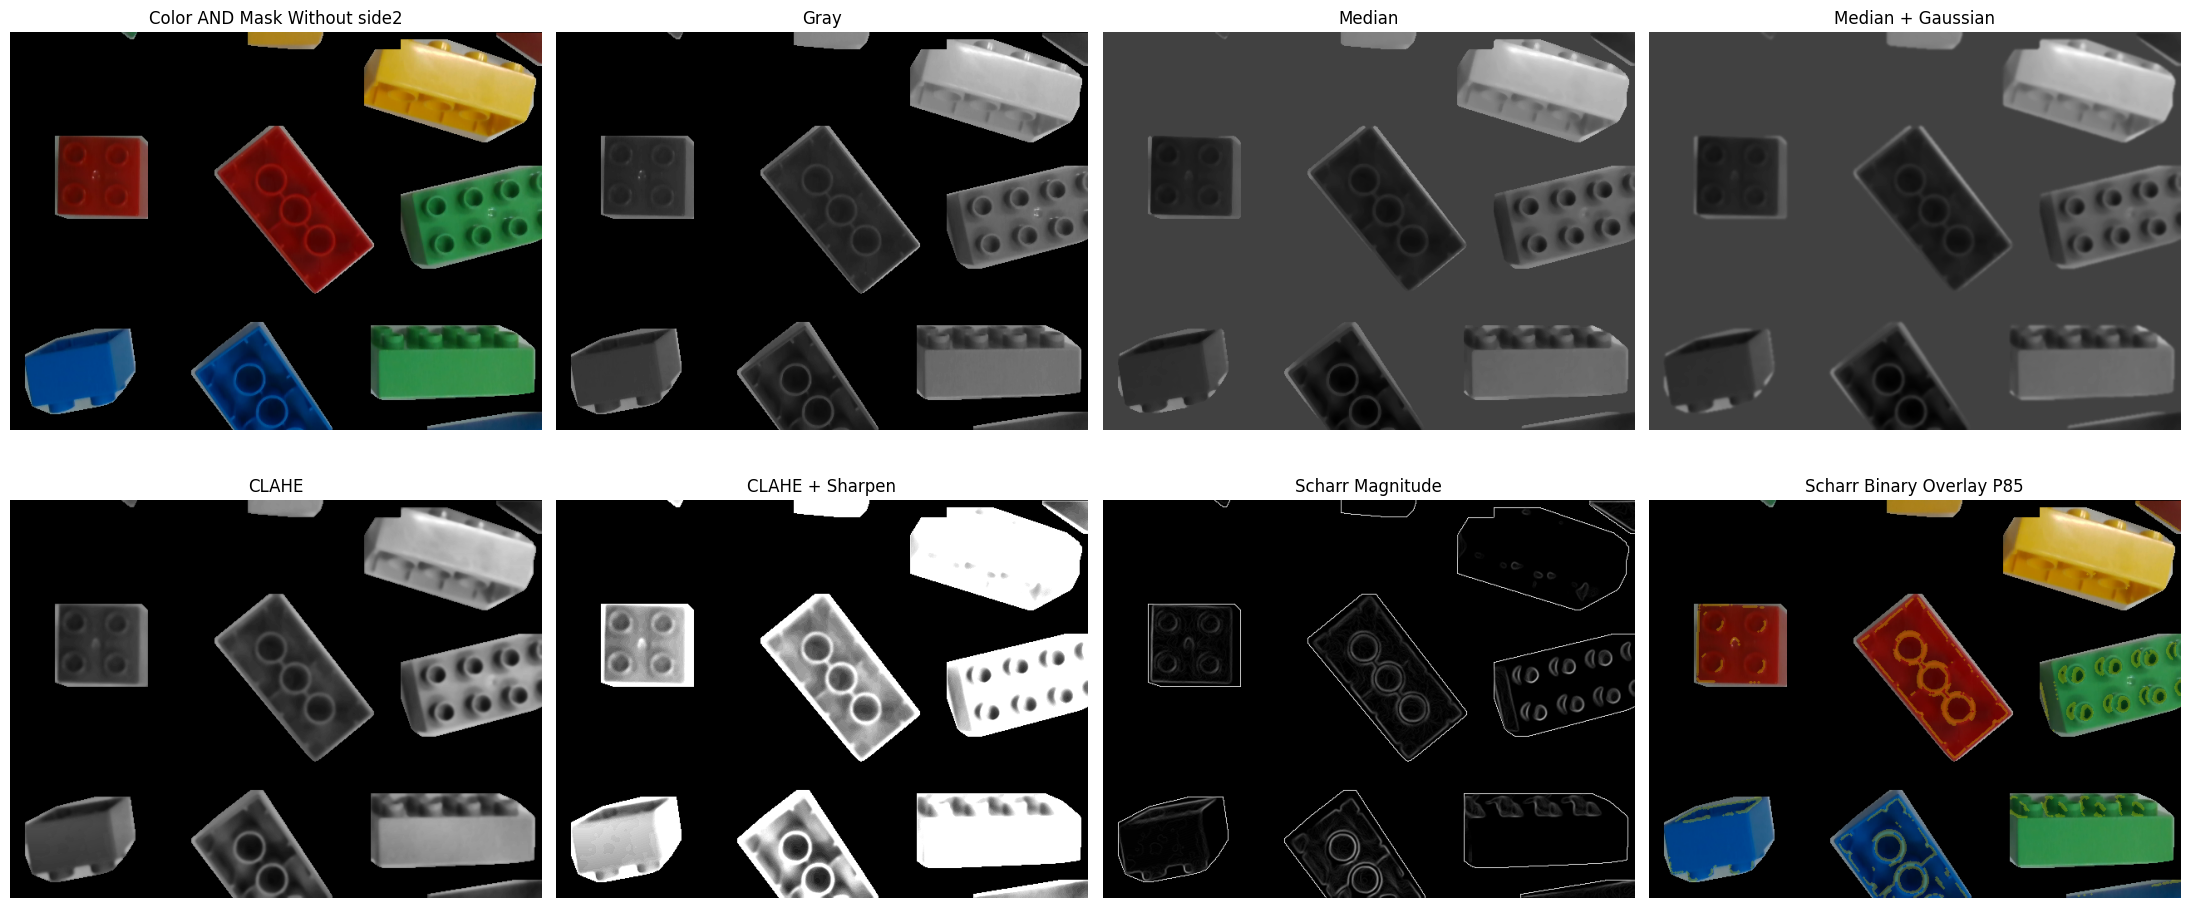

In [27]:
# =================================================================
# Median → Gaussian → CLAHE → Sharpen → Scharr 만 보기
# 입력:
#   color_no_side2_bgr
#   mask_no_side2
# =================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Gray
# ------------------------------------------------------------
gray = cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2GRAY)

# 마스크 바깥을 내부 median 값으로 채움
# 이유: 검정 배경 경계가 Scharr에서 강한 edge로 터지는 것 방지
valid_pixels = gray[mask_no_side2 > 0]

if len(valid_pixels) > 0:
    fill_value = int(np.median(valid_pixels))
else:
    fill_value = 0

gray_bg_filled = gray.copy()
gray_bg_filled[mask_no_side2 == 0] = fill_value

# ------------------------------------------------------------
# 2. Median
# ------------------------------------------------------------
median_ksize = 5
gray_median = cv2.medianBlur(gray_bg_filled, median_ksize)

# ------------------------------------------------------------
# 3. Gaussian
# ------------------------------------------------------------
gaussian_ksize = 5
gray_gaussian = cv2.GaussianBlur(
    gray_median,
    (gaussian_ksize, gaussian_ksize),
    sigmaX=0
)

# ------------------------------------------------------------
# 4. CLAHE
# ------------------------------------------------------------
clahe = cv2.createCLAHE(
    clipLimit=2,
    tileGridSize=(8, 8)
)
gray_clahe = clahe.apply(gray_gaussian)

# 마스크 바깥 제거
mask_no_side2_255 = (mask_no_side2.astype(np.uint8) * 255)

gray_clahe_masked = cv2.bitwise_and(
    gray_clahe,
    gray_clahe,
    mask=mask_no_side2_255
)

# ------------------------------------------------------------
# 5. Sharpening
# ------------------------------------------------------------
sharpen_kernel = np.array([
    [0, -1,  0],
    [-1, 7, -1],
    [0, -1,  0]
], dtype=np.float32)

gray_sharp = cv2.filter2D(gray_clahe_masked, -1, sharpen_kernel)

# ------------------------------------------------------------
# 6. Scharr Gradient
# ------------------------------------------------------------
scharr_x = cv2.Scharr(gray_sharp, cv2.CV_32F, 1, 0)
scharr_y = cv2.Scharr(gray_sharp, cv2.CV_32F, 0, 1)

scharr_mag = cv2.magnitude(scharr_x, scharr_y)

scharr_mag_u8 = cv2.normalize(
    scharr_mag,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

scharr_mag_u8 = cv2.bitwise_and(
    scharr_mag_u8,
    scharr_mag_u8,
    mask=mask_no_side2_255
)

# ------------------------------------------------------------
# 7. Scharr Binary
# ------------------------------------------------------------
scharr_percentile = 85

valid_scharr = scharr_mag_u8[mask_no_side2 > 0]

if len(valid_scharr) > 0:
    scharr_th = np.percentile(valid_scharr, scharr_percentile)
else:
    scharr_th = 0

scharr_bin = ((scharr_mag_u8 >= scharr_th) & (mask_no_side2 > 0)).astype(np.uint8) * 255

# 노이즈 정리
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
scharr_bin_clean = cv2.morphologyEx(scharr_bin, cv2.MORPH_OPEN, kernel_small)
scharr_bin_clean = cv2.morphologyEx(scharr_bin_clean, cv2.MORPH_CLOSE, kernel_small)

# ------------------------------------------------------------
# 8. Overlay
# ------------------------------------------------------------
scharr_overlay = color_no_side2_bgr.copy()
scharr_overlay[scharr_bin_clean > 0] = (0, 255, 255)

scharr_overlay = cv2.addWeighted(
    color_no_side2_bgr,
    0.75,
    scharr_overlay,
    0.25,
    0
)

# ------------------------------------------------------------
# 9. 시각화
# ------------------------------------------------------------
plt.figure(figsize=(22, 10))

plt.subplot(2, 4, 1)
plt.imshow(cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2RGB))
plt.title("Color AND Mask Without side2")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(gray_median, cmap="gray")
plt.title("Median")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(gray_gaussian, cmap="gray")
plt.title("Median + Gaussian")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(gray_clahe_masked, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(gray_sharp, cmap="gray")
plt.title("CLAHE + Sharpen")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(scharr_mag_u8, cmap="gray")
plt.title("Scharr Magnitude")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(cv2.cvtColor(scharr_overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Scharr Binary Overlay P{scharr_percentile}")
plt.axis("off")

plt.tight_layout()
plt.show()